In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/models/vagishayadav166/rmin-model-keras/keras/default/1/Untitled7.ipynb
/kaggle/input/datasets/vagishayadav166/sgr-photon-dataset/sgr_photon_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/vagishayadav166/sgr-photon-dataset/sgr_photon_dataset.csv')

In [3]:
display(df.head())

,M,b,b_over_bcrit,outcome,captured,r_min,phi_final,n_orbits,deflection_angle,n_steps
0,1.0,0.259808,0.050000,capture,1,1.999927,0.130,0.020690,NaN,26
1,1.0,0.264961,0.050992,capture,1,1.964085,0.135,0.021486,NaN,27
2,1.0,0.270115,0.051984,capture,1,1.930799,0.140,0.022282,NaN,28
3,1.0,0.275269,0.052975,capture,1,1.967731,0.140,0.022282,NaN,28
4,1.0,0.280422,0.053967,capture,1,1.935472,0.145,0.023077,NaN,29


In [4]:
display(df.describe())

,M,b,b_over_bcrit,captured,r_min,phi_final,n_orbits,deflection_angle,n_steps
count,8299.0,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,6941.000000,8299.000000
mean,1.0,116.848946,22.487590,0.163634,115.630623,3.937042,0.626600,0.772838,786.575853
std,0.0,353.296731,67.991987,0.369966,353.363281,2.429609,0.386684,1.941141,485.929198
min,1.0,0.259808,0.050000,0.000000,1.930799,0.130000,0.020690,0.003407,26.000000
25%,1.0,6.828211,1.314090,0.000000,5.425668,3.210000,0.510887,0.153407,641.000000
50%,1.0,17.519583,3.371645,0.000000,16.417836,3.355000,0.533965,0.223407,670.000000
75%,1.0,28.210954,5.429201,0.000000,27.152085,3.635000,0.578528,0.453407,726.000000
max,1.0,2598.076211,500.000000,1.000000,2597.076785,16.560000,2.635606,13.418407,3311.000000


In [5]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


M                      0
b                      0
b_over_bcrit           0
outcome                0
captured               0
r_min                  0
phi_final              0
n_orbits               0
deflection_angle    1358
n_steps                0
dtype: int64

In [6]:
print('Unique values in the outcome column:')
display(df['outcome'].unique())

Unique values in the outcome column:


array(['capture', 'escape'], dtype=object)

In [7]:
print('Relationship between outcome and captured columns:')
display(df[['outcome', 'captured']].value_counts())

Relationship between outcome and captured columns:


outcome  captured
escape   0           6941
capture  1           1358
Name: count, dtype: int64

In [8]:
df = df.drop(columns=['n_steps'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8299 entries, 0 to 8298
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   M                 8299 non-null   float64
 1   b                 8299 non-null   float64
 2   b_over_bcrit      8299 non-null   float64
 3   outcome           8299 non-null   object 
 4   captured          8299 non-null   int64  
 5   r_min             8299 non-null   float64
 6   phi_final         8299 non-null   float64
 7   n_orbits          8299 non-null   float64
 8   deflection_angle  6941 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 583.7+ KB


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Identify the column with missing values
column_to_impute = 'deflection_angle'

# Identify predictor columns (all numerical columns except the one to impute)
# 'outcome' is object type, so we exclude it for numerical regression here.
predictor_columns = ['M', 'b', 'b_over_bcrit', 'captured', 'r_min', 'phi_final', 'n_orbits']

# Separate data into known and missing `deflection_angle`
df_known_da = df[df[column_to_impute].notna()]
df_missing_da = df[df[column_to_impute].isna()]

if not df_missing_da.empty:
    # Prepare training data
    X_train = df_known_da[predictor_columns]
    y_train = df_known_da[column_to_impute]

    # Initialize and train the Random Forest Regressor model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict missing values
    X_predict = df_missing_da[predictor_columns]
    predicted_values = model.predict(X_predict)

    # Fill the missing values in the original DataFrame
    df.loc[df[column_to_impute].isna(), column_to_impute] = predicted_values
    print(f"Missing values in '{column_to_impute}' imputed using RandomForestRegressor.")
else:
    print(f"No missing values found in '{column_to_impute}'. No imputation performed.")

# Display DataFrame info to verify no more missing values in 'deflection_angle'
df.info()

Missing values in 'deflection_angle' imputed using RandomForestRegressor.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8299 entries, 0 to 8298
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   M                 8299 non-null   float64
 1   b                 8299 non-null   float64
 2   b_over_bcrit      8299 non-null   float64
 3   outcome           8299 non-null   object 
 4   captured          8299 non-null   int64  
 5   r_min             8299 non-null   float64
 6   phi_final         8299 non-null   float64
 7   n_orbits          8299 non-null   float64
 8   deflection_angle  8299 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 583.7+ KB


In [10]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [11]:
captured_and_rmin_condition = df[(df['outcome'] == 'capture') & (df['r_min'] < (2 * df['M']))]
num_captured_and_rmin_less_2M = len(captured_and_rmin_condition)

print(f"Number of 'capture' outcomes where r_min < 2M: {num_captured_and_rmin_less_2M}")

Number of 'capture' outcomes where r_min < 2M: 892


In [12]:
df_filtered = df[df['r_min'] >= (2 * df['M'])]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")
display(df_filtered.head())

Original DataFrame shape: (8299, 9)
Filtered DataFrame shape: (7407, 9)


,M,b,b_over_bcrit,outcome,captured,r_min,phi_final,n_orbits,deflection_angle
31,1.0,0.419573,0.080747,capture,1,2.001645,0.210,0.033423,3.062357
56,1.0,0.548415,0.105543,capture,1,2.000527,0.275,0.043768,3.062357
58,1.0,0.558723,0.107526,capture,1,2.001977,0.280,0.044563,3.062357
79,1.0,0.666951,0.128355,capture,1,2.000212,0.335,0.053317,3.062357
81,1.0,0.677258,0.130338,capture,1,2.001554,0.340,0.054113,3.062357


In [13]:
df = df_filtered.copy()
del df_filtered
print(f"DataFrame 'df' updated. New shape: {df.shape}")

DataFrame 'df' updated. New shape: (7407, 9)


In [14]:
print('--- Checking Data Ranges ---')

# M > 0
if (df['M'] > 0).all():
    print('M: All values are > 0. (Passed)')
else:
    print(f"M: Found {(df['M'] <= 0).sum()} values <= 0. (Failed)")

# b >= 0
if (df['b'] >= 0).all():
    print('b: All values are >= 0. (Passed)')
else:
    print(f"b: Found {(df['b'] < 0).sum()} values < 0. (Failed)")

# b/bcrit >= 0
if (df['b_over_bcrit'] >= 0).all():
    print('b_over_bcrit: All values are >= 0. (Passed)')
else:
    print(f"b_over_bcrit: Found {(df['b_over_bcrit'] < 0).sum()} values < 0. (Failed)")

# captured = {0,1}
if df['captured'].isin([0, 1]).all():
    print('captured: All values are 0 or 1. (Passed)')
else:
    print(f"captured: Found {len(df) - df['captured'].isin([0, 1]).sum()} values that are not 0 or 1. (Failed)")

# r_min > 0
if (df['r_min'] > 0).all():
    print('r_min: All values are > 0. (Passed)')
else:
    print(f"r_min: Found {(df['r_min'] <= 0).sum()} values <= 0. (Failed)")

# phi_final: finite
if df['phi_final'].notna().all():
    print('phi_final: All values are finite. (Passed)')
else:
    print(f"phi_final: Found {df['phi_final'].isna().sum()} non-finite values. (Failed)")

# deflection_angle: finite
if df['deflection_angle'].notna().all():
    print('deflection_angle: All values are finite. (Passed)')
else:
    print(f"deflection_angle: Found {df['deflection_angle'].isna().sum()} non-finite values. (Failed)")

# n_orbits >= 0
if (df['n_orbits'] >= 0).all():
    print('n_orbits: All values are >= 0. (Passed)')
else:
    print(f"n_orbits: Found {(df['n_orbits'] < 0).sum()} values < 0. (Failed)")

# n_steps was removed, so we won't check it here.
# print('n_steps: Skipping check as the column was removed.')

--- Checking Data Ranges ---
M: All values are > 0. (Passed)
b: All values are >= 0. (Passed)
b_over_bcrit: All values are >= 0. (Passed)
captured: All values are 0 or 1. (Passed)
r_min: All values are > 0. (Passed)
phi_final: All values are finite. (Passed)
deflection_angle: All values are finite. (Passed)
n_orbits: All values are >= 0. (Passed)


The DataFrame df has now been filtered to df_filtered, retaining only the rows where r_min >= 2 * M. This means that only trajectories that do not pass within the Schwarzschild radius of the black hole (if interpreted as a Schwarzschild black hole) are kept.

# TRAIN TEST SPLIT

In [15]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['M', 'b', 'b_over_bcrit']]
y = df['r_min']

# First split: 85% for training+validation, 15% for testing
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the training+validation set, split 70% for training and 15% for validation
# This means the validation set will be 15% of the original data, so 15 / (70 + 15) = 15/85 of X_train_val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5184, 3)
X_val shape: (1111, 3)
X_test shape: (1112, 3)
y_train shape: (5184,)
y_val shape: (1111,)
y_test shape: (1112,)


# NORMALIZATION

In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the *same* scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection and to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaled X_train (first 5 rows):")
display(X_train_scaled.head())
print("Scaled X_val (first 5 rows):")
display(X_val_scaled.head())
print("Scaled X_test (first 5 rows):")
display(X_test_scaled.head())

Scaled X_train (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.304647,-0.304647
1,0.0,-0.332972,-0.332972
2,0.0,-0.285973,-0.285973
3,0.0,-0.281931,-0.281931
4,0.0,-0.308306,-0.308306


Scaled X_val (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.306370,-0.306370
1,0.0,4.741733,4.741733
2,0.0,0.088812,0.088812
3,0.0,-0.285517,-0.285517
4,0.0,0.131223,0.131223


Scaled X_test (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.326980,-0.326980
1,0.0,0.832311,0.832311
2,0.0,-0.183758,-0.183758
3,0.0,-0.132638,-0.132638
4,0.0,-0.339636,-0.339636


# NEURAL NETWORK

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-25 10:09:34.960037: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [19]:
model.compile(
    loss='mse', # Mean Squared Error
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae'] # Mean Absolute Error
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [21]:
# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping]
)

Epoch 1/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 91323.5938 - mae: 89.7205 - val_loss: 701.1354 - val_mae: 13.0861
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 86.0884 - mae: 5.6510 - val_loss: 26.5295 - val_mae: 4.1350
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.1576 - mae: 3.5669 - val_loss: 14.8546 - val_mae: 3.1849
Epoch 4/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1805 - mae: 2.3841 - val_loss: 3.1376 - val_mae: 1.4595
Epoch 5/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6041 - mae: 0.8792 - val_loss: 0.7852 - val_mae: 0.5716
Epoch 6/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5884 - mae: 0.4816 - val_loss: 0.4699 - val_mae: 0.4092
Epoch 7/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3145 - mae: 0.3599 - val_loss: 0.2292 - val_mae: 0.2981
Epoch 8/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2056 - mae: 0.2927 - val_loss: 0.1733 - val_mae: 0.2705
Epoch 9/100
162/162 ━━━━━━━━━━━━━━━━

# EVALUATION

In [22]:
# Evaluate the model on the test set
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss (MSE): 0.0535
Test MAE: 0.1413


In [23]:
from sklearn.metrics import r2_score

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score on Test Set: {r2:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R-squared Score on Test Set: 1.0000


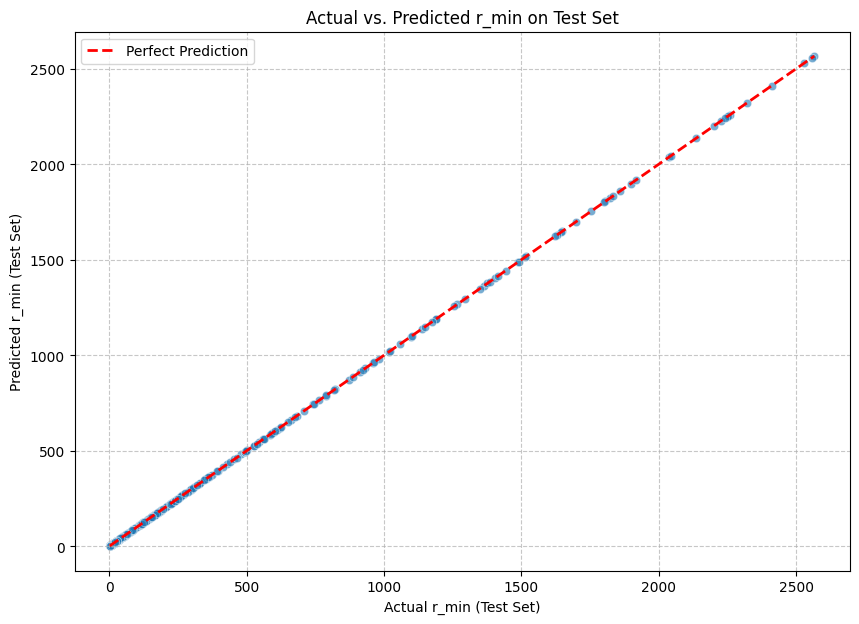

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten y_pred for plotting if it's a 2D array
y_pred_flat = y_pred.flatten()

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_flat, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual r_min (Test Set)')
plt.ylabel('Predicted r_min (Test Set)')
plt.title('Actual vs. Predicted r_min on Test Set')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()